## Check how WT amplitude depends on scale (frequency)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sys import path
path.append('../../wavelet/')
import wavelet_funcs as wf

path.append('../../signals/')
import signals as sg

import matlab.engine

In [2]:
eng = matlab.engine.start_matlab()

# Synthetic signal:

$$
z = \cos(2\pi f_1 t) + \cos(2\pi f_2 t) + \epsilon,
$$

where $f_1=0.5\,$Hz, $f_2=2\,$Hz, and $\epsilon \sim N(0, 1)$ (white noise).

In [3]:
T = 5000 # s
dt = 0.1 # s
Fs = 1/dt
nt = int(T/dt)
fsignals = np.array([0.5, 2])

t = np.arange(nt)*dt
x = np.array([sg.cosine(T, fsig, sampling_frequency=Fs)[1] for fsig in fsignals])
x = x.sum(axis=0) # sum of cosines

y = np.random.randn(nt) # noise

z = x + y # noisy sum of cosines

### Compute CWT of the signal, $\epsilon$, and of the two cosines without the noise. Call CWT coefficients $W$

In [5]:
cwt_x = wf.matlab_cwt(eng, x, Fs, voices_per_octave=24)
cwt_y = wf.matlab_cwt(eng, y, Fs, voices_per_octave=24)
cwt_z = wf.matlab_cwt(eng, z, Fs, voices_per_octave=24)

## MATLAB's cwt computes $L^1$-normalized CWT (call it $W$) => For $W$ computed from $z$, $|W|(f)$ ($f$ is frequency) should show two peaks standing on a background, and the background $\propto \sqrt{f}$. The peaks should have nearly identical maxima (since $L^1$ norm)

## Plot time-averaged $|W|$ against $f$ for signal $z$, and for the white noise $y$, to check that

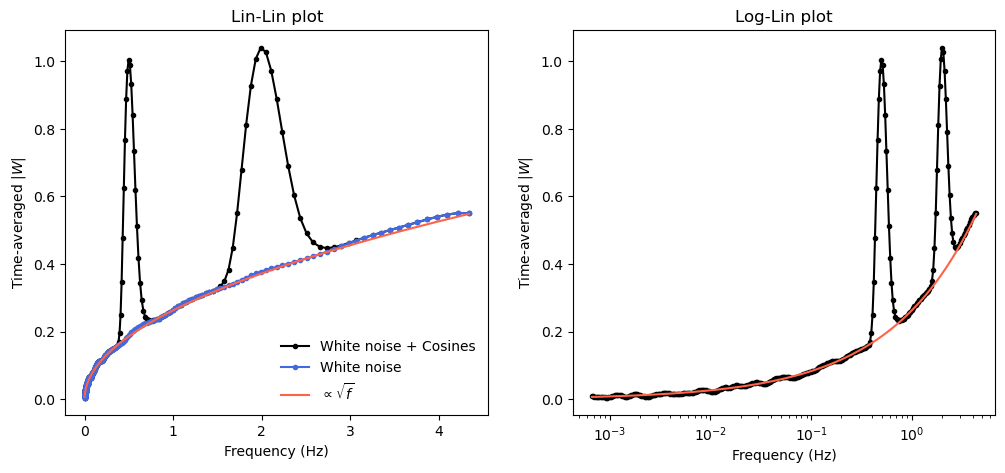

In [7]:
f, (ax,ax1) = plt.subplots(1,2,figsize=(12,5))

k = 3.8

ax.plot(cwt_z.f, cwt_z.wt_amp.mean('t'), color='k', marker='.', label='White noise + Cosines')
ax.plot(cwt_y.f, cwt_y.wt_amp.mean('t'), color='royalblue', marker='.', label='White noise')
ax.plot(cwt_z.f, np.sqrt(cwt_z.f)/k, color='tomato', label=r'$\propto\sqrt{f}$')
ax.legend(frameon=False)
ax.set(xlabel='Frequency (Hz)', ylabel = r'Time-averaged $|W|$', title='Lin-Lin plot')

ax1.plot(cwt_z.f, cwt_z.wt_amp.mean('t'), marker='.', color='k',)
# ax1.plot(cwt_y.f, cwt_y.wt_amp.mean('t'), color='royalblue', marker='.', label='White noise')
ax1.plot(cwt_z.f, np.sqrt(cwt_z.f)/k, color='tomato', label=r'$\frac{\sqrt{f}}{2.7}$, coming from white noise')
ax1.set(xlabel='Frequency (Hz)', ylabel = r'Time-averaged $|W|$', title='Log-Lin plot')
ax1.set_xscale('log')

## $|W|/\sqrt{f}$ will show flat background when plot against $f$. $|W|/\sqrt{f}$ is proportional to $L^2$-normalized wavelet amplitude.

## For $L^2$ normalization, peaks in $|W|^2/f$ corresponding to cosines with identical oscillation amplitudes should have approximately the same area.

## $|W|^2/f$ has flat background as $|W|^2/f$ of white noise is flat and proportional to $\sigma^2 ||\psi||^2_2$, where $\sigma^2$ is the noise variance and $\psi$ is the wavelet.

## Plot $|W|^2/f$ against $f$ for signal $z$

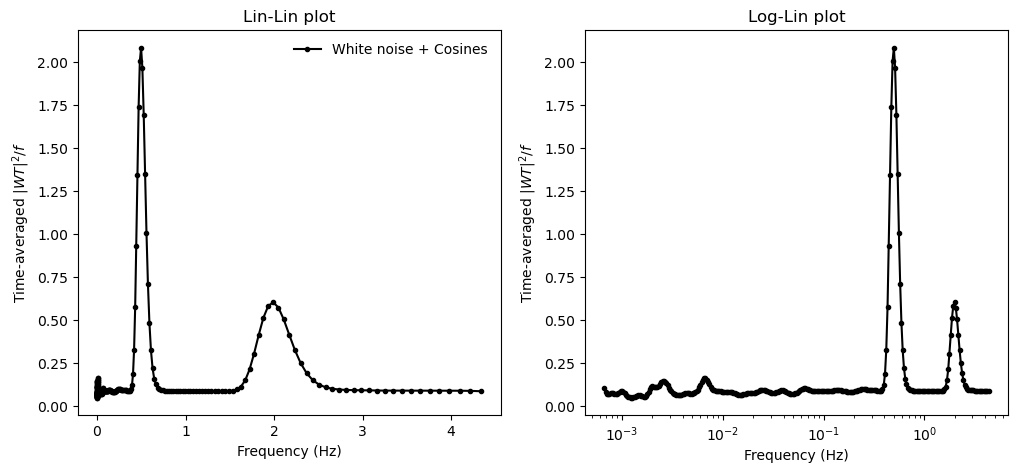

In [283]:
f, (ax,ax1) = plt.subplots(1,2,figsize=(12,5))

ax.plot(cwt_z.f, (cwt_z.wt_amp**2).mean('t')/cwt_z.f, color='k', marker='.', label='White noise + Cosines')
ax.legend(frameon=False)
ax.set(xlabel='Frequency (Hz)', ylabel = r'Time-averaged $|WT|^2/f$', title='Lin-Lin plot')

ax1.plot(cwt_z.f, (cwt_z.wt_amp**2).mean('t')/cwt_z.f, marker='.', color='k',)
ax1.set(xlabel='Frequency (Hz)', ylabel = r'Time-averaged $|WT|^2/f$', title='Log-Lin plot')
ax1.set_xscale('log')

## Plot $|W|^2/f$ against $f$ for noiseless sum of the same two cosines $x$

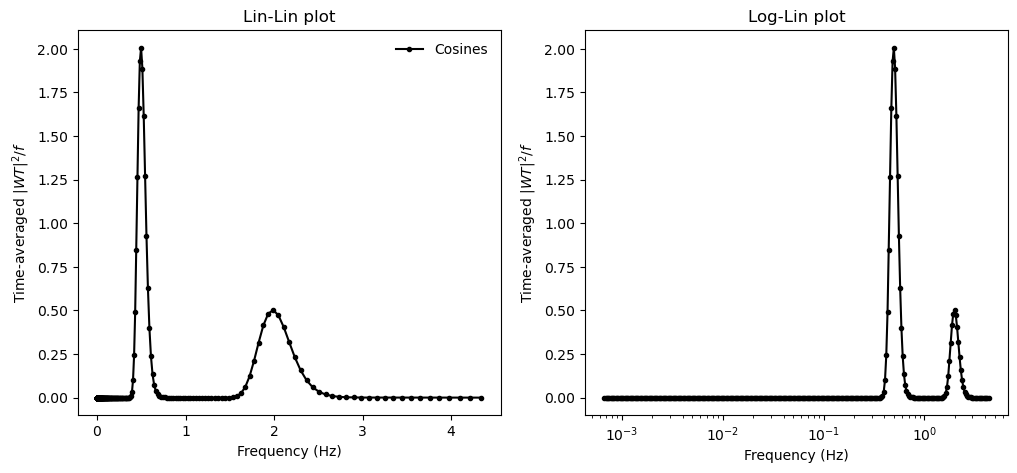

In [8]:
f, (ax,ax1) = plt.subplots(1,2,figsize=(12,5))

ax.plot(cwt_x.f, (cwt_x.wt_amp**2).mean('t')/cwt_z.f, color='k', marker='.', label='Cosines')
ax.legend(frameon=False)
ax.set(xlabel='Frequency (Hz)', ylabel = r'Time-averaged $|WT|^2/f$', title='Lin-Lin plot')

ax1.plot(cwt_x.f, (cwt_x.wt_amp**2).mean('t')/cwt_z.f, marker='.', color='k',)
ax1.set(xlabel='Frequency (Hz)', ylabel = r'Time-averaged $|WT|^2/f$', title='Log-Lin plot')
ax1.set_xscale('log')

# Integrate CWT computed from noiseless cosines along frequency using different ways

### Select integration intervals — two frequency bands capturing the two spectral peaks of the two cosines. Show these bands

In [46]:
amp = cwt_x.wt_amp.mean('t')/np.sqrt(cwt_z.f)
amp = amp[::-1] # sort in asscending frequency order

In [47]:
peak_bands = [
    slice(0.25, 1.2),
    slice(1.22, 4.3),
]

[Text(0.5, 0, 'Frequency (Hz)'),
 Text(0, 0.5, 'Time-averaged $|WT|/\\sqrt{f}$')]

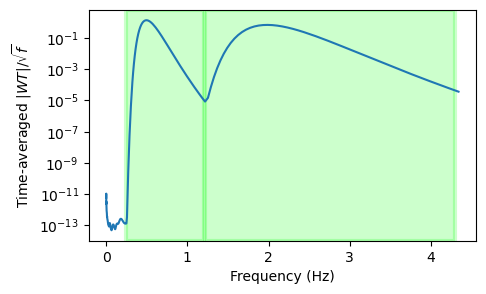

In [48]:
f, ax = plt.subplots(figsize=(5,3))
ax.semilogy(amp.f, amp)
for b in peak_bands:
    ax.axvspan(b.start, b.stop, color='lime', alpha=0.2, lw=3)

ax.set(xlabel='Frequency (Hz)', ylabel = r'Time-averaged $|WT|/\sqrt{f}$')

## 1. Integrate |W|/$\sqrt{f}$ : 

In [49]:
amp_integral = amp.integrate('f').item()

In [50]:
peak_areas = []
for b in peak_bands:
    val = amp.sel(f=b).integrate('f')
    peak_areas.append(val.item())

In [52]:
print(f"0.5-Hz peak area: {peak_areas[0]:.4f}")
print(f"2-Hz peak area: {peak_areas[1]:.4f}")

0.5-Hz peak area: 0.2353
2-Hz peak area: 0.4705


#### The two integrals should represent something like total amplitude, and should (by our intention, not by definition) ideally be the same for the two cosines of identical oscillation amplitudes, but differnet frequencies. They are not the same, so the computed area makes little physical meaning. It isn't clear what it represents really

## 2. Integrate |W|, divide by frequency band width 

In [53]:
amp = cwt_x.wt_amp.mean('t')
amp = amp[::-1] # sort in asscending frequency order

In [54]:
peak_areas = []
for b in peak_bands:
    val = amp.sel(f=b).integrate('f') / (b.stop - b.start)
    peak_areas.append(val.item())

In [55]:
print(f"0.5-Hz peak area: {peak_areas[0]:.4f}")
print(f"2-Hz peak area: {peak_areas[1]:.4f}")

0.5-Hz peak area: 0.1786
2-Hz peak area: 0.2203


#### The two integrals differ, which again makes little physical sense for two cosines with identical amplitudes. The integrals differ probably because they blend several things:
- higher-frequency peak is broader, but has the same height in $L^1$-normed $|W|$
- higher-frequency peak stands on higher noise background because the latter $\propto\sqrt{f}$
- Other things?

## 3. Integrate $|W|^2/f$

In [56]:
p = (cwt_x.wt_amp**2).mean('t')/cwt_z.f # *cwt_z.scale
p = p[::-1] # sort in asscending frequency order

In [57]:
peak_areas = []
for b in peak_bands:
    val = p.sel(f=b).integrate('f')
    peak_areas.append(val.item())

In [58]:
print(f"0.5-Hz peak area: {peak_areas[0]:.4f}")
print(f"2-Hz peak area: {peak_areas[1]:.4f}")

0.5-Hz peak area: 0.2303
2-Hz peak area: 0.2303


#### The two integrals are equal, which DOES MAKE SENSE, because the two cosines have the same amplitude so their powers are the same.

## Note, above we integrated $noiseless$ sum of two cosines

## See how adding noise affects the integrals of the two peaks in $|W|^2/f$:

In [59]:
p2 = (cwt_z.wt_amp**2).mean('t')/cwt_z.f # *cwt_z.scale
p2 = p2[::-1] # sort in asscending frequency order

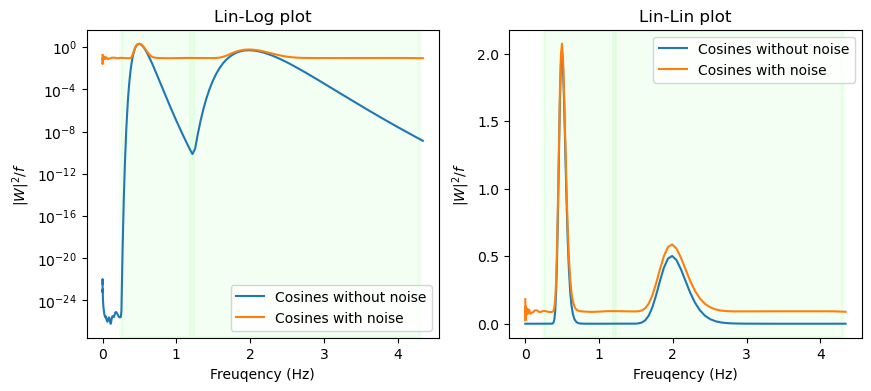

In [63]:
f, (ax,ax1) = plt.subplots(1,2, figsize=(10,4), sharey=False)
ax.semilogy(p.f, p, label='Cosines without noise')
ax.semilogy(p2.f, p2, label='Cosines with noise')

ax1.plot(p.f, p, label='Cosines without noise')
ax1.plot(p2.f, p2, label='Cosines with noise')
ax.legend()
ax1.legend()

ax.set(title='Lin-Log plot',
       ylabel='$|W|^2/f$',
       xlabel='Freuqency (Hz)'
      )
ax1.set(title='Lin-Lin plot',
       ylabel='$|W|^2/f$',
       xlabel='Freuqency (Hz)'
      )

for axi in (ax,ax1):
    for b in peak_bands:
        axi.axvspan(b.start, b.stop, color='lime', alpha=0.05, lw=3)

In [64]:
peak_areas = []
for b in peak_bands:
    val = p2.sel(f=b).integrate('f')
    peak_areas.append(val.item())

In [65]:
print(f"0.5-Hz peak area: {peak_areas[0]:.4f}")
print(f"2-Hz peak area: {peak_areas[1]:.4f}")

0.5-Hz peak area: 0.3116
2-Hz peak area: 0.4968


## The integral of the 2-Hz peak is larger because it integrates not only the peak, but also the flat noise "floor", and over a wider frequency interval than for 0.5-Hz peak (wider frequency interval for 2-Hz peak because this peak is itself wider! — we want to integrate over the entire peak)

## We want a measure representing signal's power in a given band, which is not contaminated by the noise floor. To do that, subtract from $|W|^2/f$ it's mean value, over entire time and over frequency band containing no TGF/heartrate/respiration. Then integrate that difference.

- Note, however: Strictly, if $z=x+y$, their squared wavelet amplitudes: $|W_z|^2=|W_x|^2 + |W_y|^2 + 2Re(W_xW^*_y)$, and $2Re(W_xW^*_y)=0$ only if x and y (their Wavelet spectra?) are uncorrelated. For camera noise, movement artifacts it is probably true (???)... Can be tested by computing the cross-spectrum
- Subtraction in this numerical experiment works with squared amplitude because the noise and the cosines are independent, hence $Re(W_xW^*_y)=0$

In [66]:
band_noise = slice(4, 4.3)
mean_noise = p2.sel(f=band_noise).mean('f')

p2_denoise = p2 - mean_noise

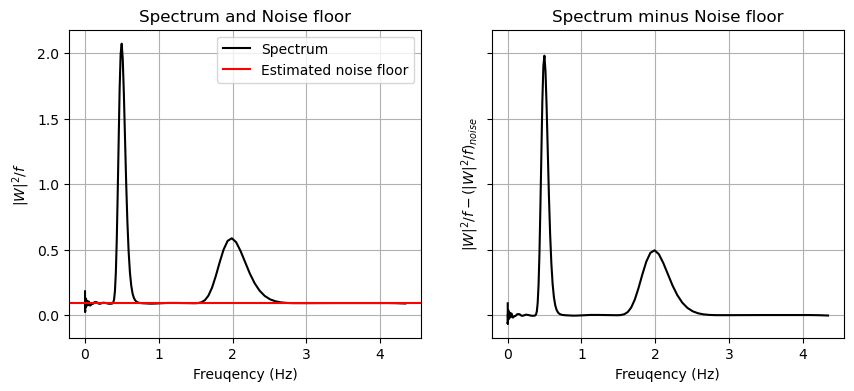

In [68]:
f, (ax,ax1) = plt.subplots(1,2,figsize=(10,4), sharey=True)

ax.plot(p2.f, p2, color='k', label='Spectrum')
ax.axhline(mean_noise, label='Estimated noise floor', color='r')
ax.legend()
ax.set(title='Spectrum and Noise floor',
       ylabel='$|W|^2/f$',
       xlabel='Freuqency (Hz)'
      )

ax1.plot(p2.f, p2_denoise, color='k')
ax1.set(title='Spectrum minus Noise floor',
       ylabel='$|W|^2/f - (|W|^2/f)_{noise}$',
       xlabel='Freuqency (Hz)'
      )

for axi in (ax,ax1):
    axi.grid()

In [69]:
peak_areas = []
for b in peak_bands:
    val = p2_denoise.sel(f=b).integrate('f')
    peak_areas.append(val.item())

In [70]:
print(f"0.5-Hz peak area: {peak_areas[0]:.4f}")
print(f"2-Hz peak area: {peak_areas[1]:.4f}")

0.5-Hz peak area: 0.2265
2-Hz peak area: 0.2251


## The two integrals are now nearly identical, after subtraction of the noise floor

# The computed integrals should be proportional to signal's power in the corresponding bands. If it is so, the integral should be proportional to oscillation amplitude. Check this (no noise):

In [71]:
amps = np.arange(1, 21, 3)
signals = [sg.cosine(T, 0.02, Fs, amplitude=amp)[1] for amp in amps]

(1000.0, 1400.0)

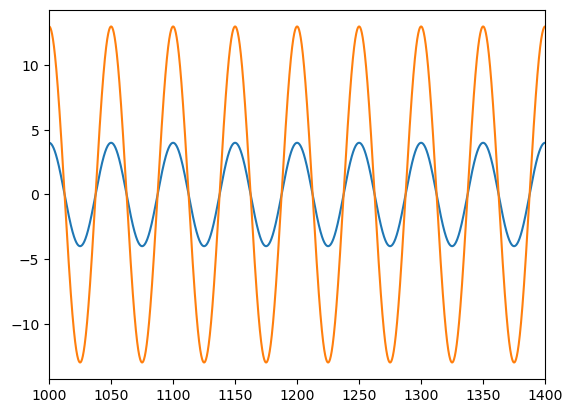

In [72]:
plt.plot(t, signals[1], t, signals[4])
plt.xlim(1000, 1400)

In [73]:
cwts = [wf.matlab_cwt(eng, s, Fs) for s in signals]
cwt_pows = [(r.wt_amp**2).mean('t')/r.f for r in cwts]

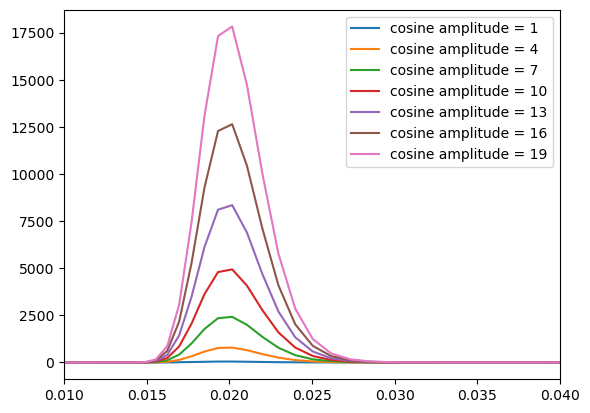

In [74]:
for r, a in zip(cwt_pows, amps):
    plt.plot(r.f, r, label=f"cosine amplitude = {a}")
plt.xlim(0.01, 0.04)
plt.legend()

In [75]:
band_powers = [r[::-1].sel(f=slice(0.01, 0.04)).integrate('f').item() for r in cwt_pows]

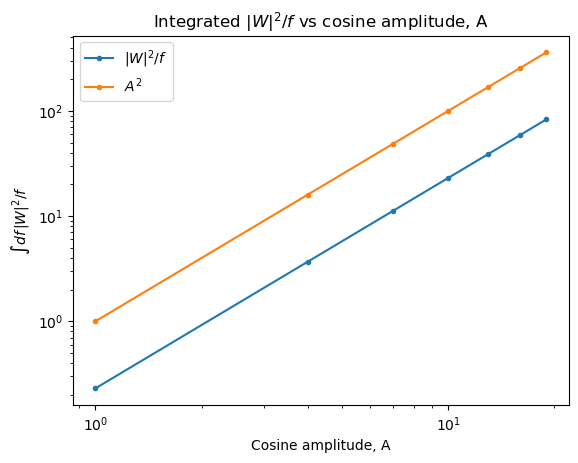

In [77]:
f, ax = plt.subplots()
ax.loglog(amps, band_powers, label='$|W|^2/f$', marker='.')
ax.loglog(amps, np.array(amps)**2, label='$A^2$', marker='.')
ax.set(ylabel='$\int df\,|W|^2/f$',
       xlabel='Cosine amplitude, A',
       title='Integrated $|W|^2/f$ vs cosine amplitude, A',
      )
ax.legend()

In [78]:
band_powers

[0.23032917762054972,
 3.6852668419287955,
 11.286129703404704,
 23.032917762053327,
 38.92563101786973,
 58.96426947086073,
 83.14883312101118]

### This (band-)integrated $|W|^2/f$ scales as squared amplitude of oscillation, as power of cosine does. This simply confirms that (band-)integrated $|W|^2/f$ is proportional to signal's power in a frequency band.

## Same, but with noisy cosine

In [100]:
amps = np.concat((np.arange(0.01, 1, 0.1), np.arange(5, 21, 5)))
signals = [sg.cosine(T, 0.02, Fs, amplitude=amp)[1]+np.random.randn(nt) for amp in amps]

(1000.0, 1400.0)

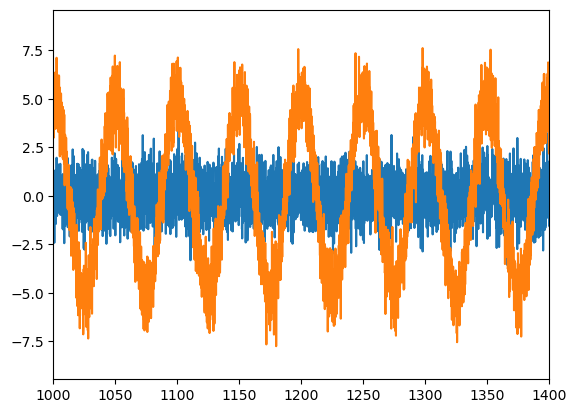

In [121]:
plt.plot(t, signals[0], t, signals[10])
plt.xlim(1000, 1400)

In [105]:
cwts = [wf.matlab_cwt(eng, s, Fs) for s in signals]
cwt_pows = [(r.wt_amp**2).mean('t')/r.f for r in cwts]

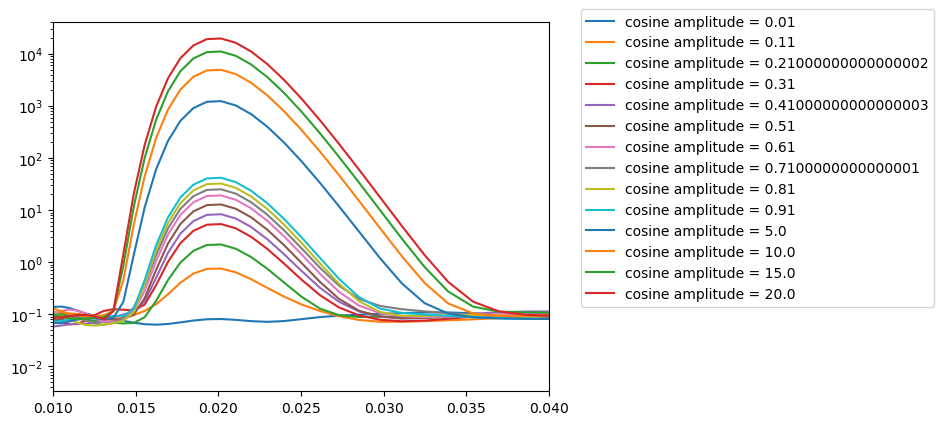

In [120]:
for r, a in zip(cwt_pows, amps):
    plt.plot(r.f, r, label=f"cosine amplitude = {a}")
plt.xlim(0.01, 0.04)
plt.legend(bbox_to_anchor=(1.05,0.21))
plt.yscale('log')

In [107]:
band_powers = [r[::-1].sel(f=slice(0.01, 0.04)).integrate('f').item() for r in cwt_pows]
band_powers_noise = [r[::-1].sel(f=slice(0.04, 0.05)).integrate('f').item() for r in cwt_pows]

band_powers_noiseSubtracted = np.array(band_powers) - np.array(band_powers_noise)

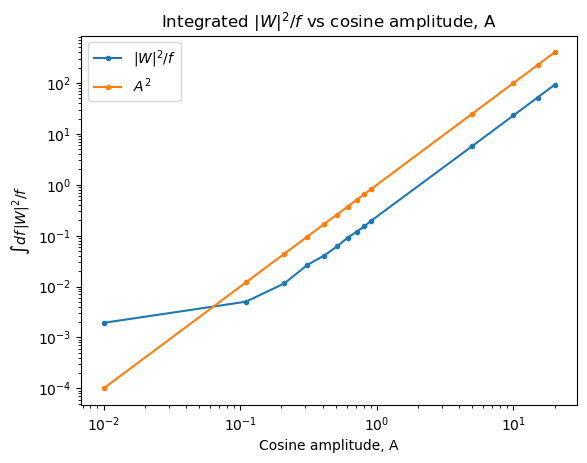

In [108]:
f, ax = plt.subplots()
ax.loglog(amps, band_powers_noiseSubtracted, label='$|W|^2/f$', marker='.')
ax.loglog(amps, np.array(amps)**2, label='$A^2$', marker='.')
ax.set(ylabel='$\int df\,|W|^2/f$',
       xlabel='Cosine amplitude, A',
       title='Integrated $|W|^2/f$ vs cosine amplitude, A',
      )
ax.legend()

### For too low amplitude $A$ (given noise sigma=1), the integral is biased (imprecise noise estimate?)